# 1. Setup and Data Preparation
First, we import the necessary libraries and load the dataset. We normalize the pixel values to a range between 0 and 1 for better training stability.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

# Load the dataset (we don't need the labels for training an autoencoder)
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize and reshape
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(f"Training shape: {x_train.shape}") # (60000, 28, 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)


# 2. Define the Autoencoder Architecture
We'll use a Subclassing API approach. This allows us to separate the encoder (compression) and decoder (reconstruction) into two distinct components.

In [ ]:
class Autoencoder(Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim

    # Encoder: Flatten 28x28 image to 784, then compress to latent_dim
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'),
    ])

    # Decoder: Expand back to 784, then reshape to 28x28
    self.decoder = tf.keras.Sequential([
      layers.Dense(784, activation='sigmoid'),
      layers.Reshape((28, 28))
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

# Initialize the model with a bottleneck of 64 dimensions
latent_dim = 64
autoencoder = Autoencoder(latent_dim)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

# 3. Training the Model
In an autoencoder, the input is the target. We want the model to learn to output exactly what we gave it.


In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0240 - val_loss: 0.0134
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0117 - val_loss: 0.0108
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0095 - val_loss: 0.0094
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0092 - val_loss: 0.0092
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0091 - val_loss: 0.0092
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0090 - val_loss: 0.0090
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0089 - val_loss: 0.0090
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0088 - val_loss: 0.0090
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0088 - val_loss: 0.0089


# 4. Visualizing the Results
To evaluate the model, we compare the original images from the test set with their reconstructed versions produced by the autoencoder.


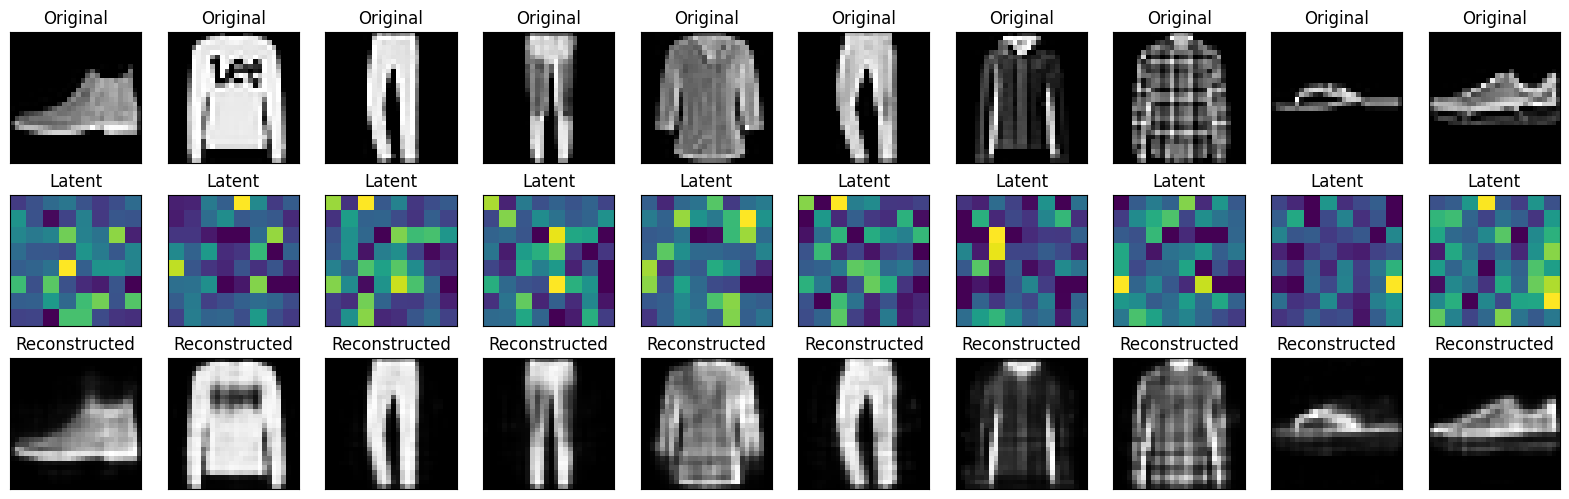

In [ ]:
# Pass the test images through the autoencoder
encoded_imgs = autoencoder.encoder(x_test).numpy()
reconstructed_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 10
plt.figure(figsize=(20, 6)) # Increased height for the third row
for i in range(n):
  # Display Original
  ax = plt.subplot(3, n, i + 1) # Changed to 3 rows
  plt.imshow(x_test[i])
  plt.title("Original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Display Latent Vector Heatmap
  ax = plt.subplot(3, n, i + 1 + n) # Second row for latent vector
  # Reshape latent vector for better visualization if possible (e.g., 64 -> 8x8)
  if encoded_imgs.shape[1] == 64:
      latent_display = encoded_imgs[i].reshape(8, 8)
  else:
      latent_display = encoded_imgs[i].reshape(1, -1) # Display as a single row if not square
  plt.imshow(latent_display, cmap='viridis') # Use a colormap for heatmap
  plt.title("Latent")
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Display Reconstruction
  ax = plt.subplot(3, n, i + 1 + 2*n) # Third row for reconstruction
  plt.imshow(reconstructed_imgs[i])
  plt.title("Reconstructed")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

### Visualizing Multiple Latent Vector Heatmaps and Generated Outputs
Below, we generate 10 random latent vectors, visualize their heatmaps, and display the images produced by passing these latent vectors through the decoder.

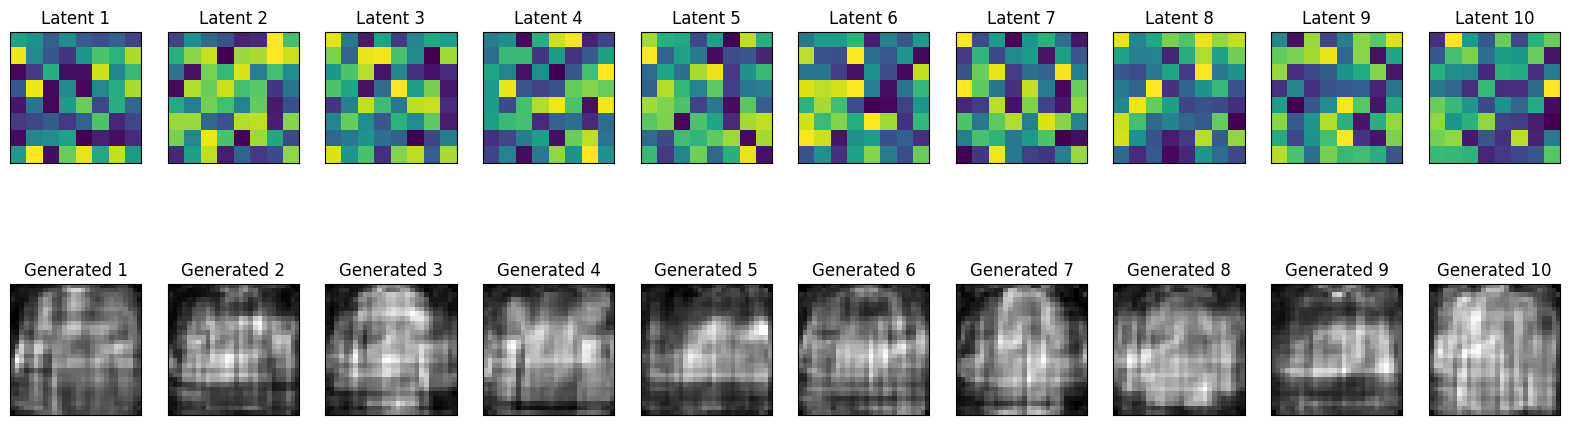

In [ ]:
n = 10
plt.figure(figsize=(20, 6))

# Generate 10 random latent vectors
random_latent_vectors = tf.random.uniform(shape=(n, latent_dim))
decoded_imgs = autoencoder.decoder(random_latent_vectors).numpy()

for i in range(n):
  # Display Latent Vector Heatmap
  ax = plt.subplot(2, n, i + 1)
  # Reshape latent vector for better visualization (e.g., 64 -> 8x8)
  if latent_dim == 64:
      latent_display = random_latent_vectors[i].numpy().reshape(8, 8)
  else:
      latent_display = random_latent_vectors[i].numpy().reshape(1, -1) # Display as a single row if not square
  plt.imshow(latent_display, cmap='viridis') # Use a colormap for heatmap
  plt.title(f"Latent {i+1}")
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Display Generated Image
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title(f"Generated {i+1}")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()